In [464]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection

In [465]:
# IMPORT 
# import graph de l'aéroport
chemin_xml = "../data/airportsAndCoordAndPop.graphml"
graph  = nx.read_graphml(chemin_xml)
# conversion du graph et attribution des caractéristiques aux noeuds
data_0=from_networkx(graph, group_node_attrs=["lon", "lat", "population"])

Tableau récapitulatif : taille, densité, degrés, connexité.

In [466]:
# table des aéroports (un aéroport par ligne, même ordre que data_0)
N = data_0.num_nodes
lon = data_0.x[:, 0].numpy()
lat = data_0.x[:, 1].numpy()
pop = data_0.x[:, 2].numpy()
src_idx = data_0.edge_index[0].numpy()
dst_idx = data_0.edge_index[1].numpy()

# les arêtes sont stockées dans les deux sens : degré = nombre d'occurrences en position 0
deg = np.bincount(src_idx, minlength=N)

df = pd.DataFrame({
    "ville": list(data_0["city_name"]),
    "pays": list(data_0["country"]),
    "lon": lon, "lat": lat, "population": pop, "degre": deg,
})


def haversine(lon1, lat1, lon2, lat2):
    """distance en km sur la sphère (formule de haversine)"""
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))


nb_aretes = data_0.edge_index.size(1) // 2
print('Degres = nb routes')
print('Coefficient de clustering moyen = Voisin de mes voisin qui sont aussi mes voisins')
resume = pd.Series({
    "Aéroports (nœuds)": N,
    "Routes (arêtes non orientées)": nb_aretes,
    "Degré moyen": round(deg.mean(), 1),
    "Degré médian": int(np.median(deg)),
    "Degré max": int(deg.max()),
    "Groupes d'aéroports": nx.number_connected_components(graph),
    "Coefficient de clustering moyen": round(nx.average_clustering(graph), 3),
    "Nombre de pays": df["pays"].nunique(),
}, name="valeur").to_frame()
resume

Degres = nb routes
Coefficient de clustering moyen = Voisin de mes voisin qui sont aussi mes voisins


,valeur
Aéroports (nœuds),3363.000
Routes (arêtes non orientées),13547.000
Degré moyen,8.100
Degré médian,3.000
Degré max,248.000
Groupes d'aéroports,6.000
Coefficient de clustering moyen,0.493
Nombre de pays,212.000


In [467]:
top_pays = (df.groupby("pays")
              .agg(aeroports=("ville", "size"), degre_moyen=("degre", "mean"), pop_mediane=("population", "median"))
              .sort_values("aeroports", ascending=False).head(10).round(1))
display(top_pays)

top_hubs = df.sort_values("degre", ascending=False).head(10)[["ville", "pays", "degre", "population"]]
display(top_hubs)

,aeroports,degre_moyen,pop_mediane
pays,,,
USA,650,9.6,19249.0
CANADA,243,4.6,10000.0
AUSTRALIA,207,5.3,10000.0
BRAZIL,105,5.5,39150.0
CHINA,93,14.7,1350150.0
PAPUA_NEW_GUINEA,92,3.4,10000.0
RUSSIA,70,9.7,245959.5
JAPAN,69,9.1,67658.0
M&Eacute;XICO#MEXICO,59,8.2,77236.0


,ville,pays,degre,population
165,Paris,FRANCE,248,2138551.0
144,London,UNITED_KINGDOM,240,346765.0
133,Frankfurt,GERMANY,234,10000.0
106,Amsterdam,THE_NETHERLANDS,191,741636.0
66,Chicago,USA,183,2696555.0
156,Moscow,RUSSIA,179,10381222.0
86,New York,USA,178,10000.0
65,Atlanta,USA,171,463878.0
67,Dallas/Fort Worth,USA,147,10000.0
72,Houston,USA,144,2304580.0


Nb de onnexions par aéroport

In [468]:
pays = data_0['country']
ville = data_0['city_name']
# décompte des occurrences de chaque pays
#from collections import Counter
#freq = Counter(pays)
#print(freq)  # Output: Counter({'c': 3, 'a': 2, 'b': 1})   

import pandas as pd
lespays=pd.Series(pays).value_counts()

# nombre de connexions  par aéroport
edge=data_0.edge_index 
nb_connection = edge.size(1)
print(nb_connection)
# nombre de connexions par aéroport

nb_connection_sortantes = pd.Series(edge[0].tolist()).value_counts().rename_axis('airport').reset_index(name='nb_sortantes')
# stat sur les connexions sortantes par aéroport
# hum , j'ai l'impression que le graph n'est pas dirigé: les connexions entrantes et sortantes sont similaires
nb_connection_entrantes = pd.Series(edge[1].tolist()).value_counts().rename_axis('airport').reset_index(name='nb_entrantes')

    

27094


## Qualité des données

Population = 10 000 : 49.75% des aéroports (valeur par défaut probable)


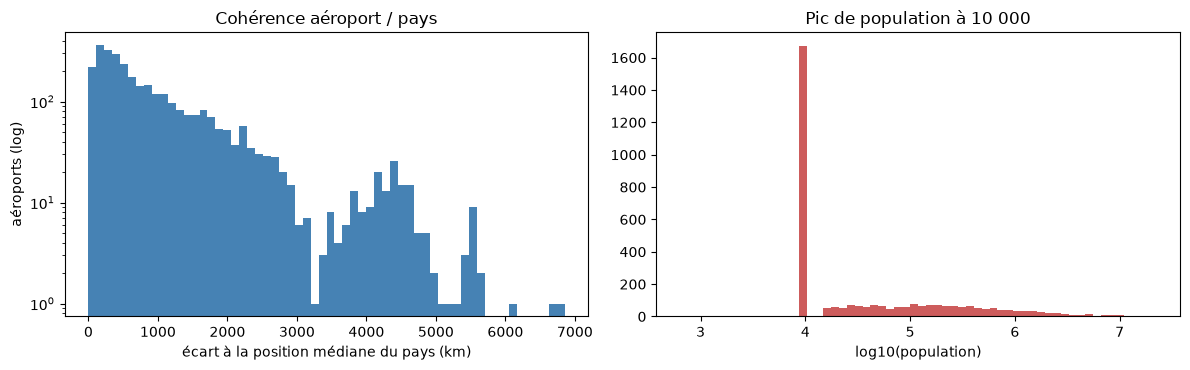

,ville,pays,ecart_km
75,Johnston Island,USA,6852.0
82,Midway Island,USA,6736.0
1648,Hagfors,USA,6101.0
78,Kauai Island,USA,5650.0
1114,Petropavlovsk-Kamchats,RUSSIA,5628.0
8,Honolulu,USA,5577.0
79,Lanai City,USA,5534.0
77,Kona,USA,5532.0
83,Hoolehua,USA,5521.0
80,Kalaupapa,USA,5507.0


In [469]:
# Beaucoup d'aéroports ont exactement le même nombre en population (peut être un plafond ou une valeur par défault)
part_10k = (df["population"] == 10000).mean()
print(f"Population = 10 000 : {part_10k:.2%} des aéroports (valeur par défaut probable)")

# pays : distance entre un aéroport et la position médiane de son pays
# (pays avec au moins 5 aéroports, pour que la médiane soit fiable)
taille = df.groupby("pays")["ville"].transform("size")
ref = df[taille >= 5].groupby("pays")[["lon", "lat"]].median().rename(columns={"lon": "lon_ref", "lat": "lat_ref"})
chk = df.join(ref, on="pays").dropna(subset=["lon_ref"]).copy()
chk["ecart_km"] = haversine(chk["lon"], chk["lat"], chk["lon_ref"], chk["lat_ref"])

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(chk["ecart_km"], bins=60, color="steelblue")
ax[0].set_yscale("log")
ax[0].set_xlabel("écart à la position médiane du pays (km)")
ax[0].set_ylabel("aéroports (log)")
ax[0].set_title("Cohérence aéroport / pays")
ax[1].hist(np.log10(df["population"]), bins=60, color="indianred")
ax[1].set_xlabel("log10(population)")
ax[1].set_title("Pic de population à 10 000")
plt.tight_layout()
plt.show()


display(chk.sort_values("ecart_km", ascending=False).head(12)[["ville", "pays", "ecart_km"]].round(0))


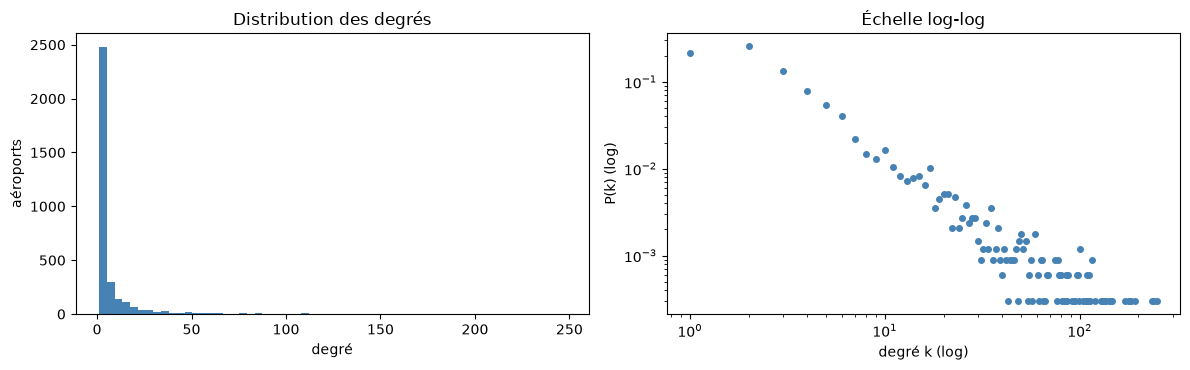

In [470]:
# la majorité des aéroports ont peu de connexions (moins de 20) et quelques hubs en ont beaucoup (jusqu'à 250)
vals = pd.Series(deg).value_counts().sort_index()
p_k = vals / vals.sum()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(deg, bins=60, color="steelblue")
ax[0].set_xlabel("degré")
ax[0].set_ylabel("aéroports")
ax[0].set_title("Distribution des degrés")
ax[1].loglog(p_k.index, p_k.values, "o", ms=4, color="steelblue")
ax[1].set_xlabel("degré k (log)")
ax[1].set_ylabel("P(k) (log)")
ax[1].set_title("Échelle log-log")
plt.tight_layout()
plt.show()

df_fusionne = pd.merge(nb_connection_sortantes, nb_connection_entrantes, on="airport", how="outer")

Le `nx.draw` est illisible dû au nombre de nodes concntrés sur une petite zone. On préfère donc passer par `plt` pour tout les affichages de cartes.

taille = population, couleur = degré


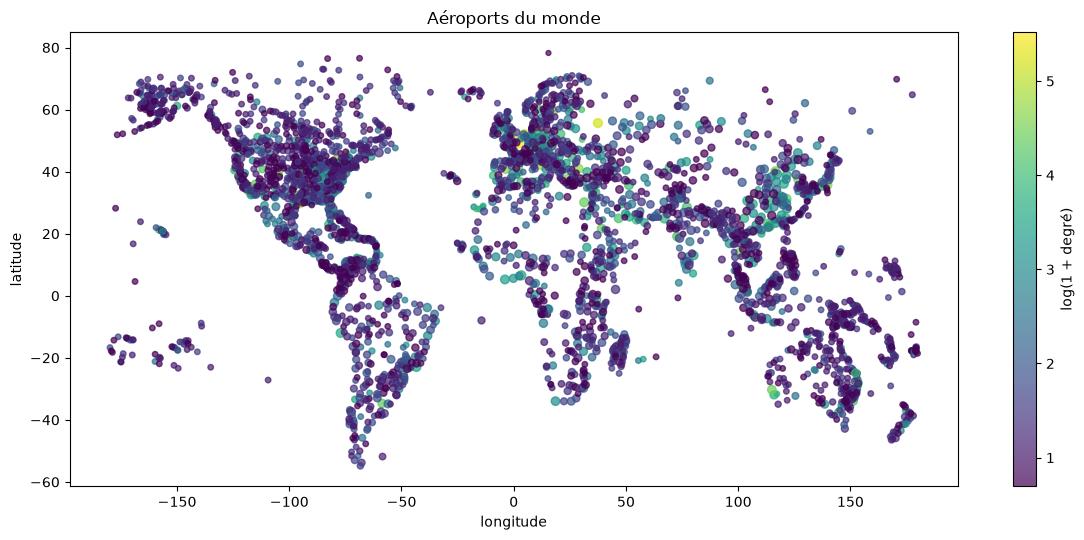

In [471]:
# carte des aéroports : couleur = degré, taille = population
fig, ax = plt.subplots(figsize=(12, 5.5))
sc = ax.scatter(df["lon"], df["lat"], c=np.log1p(df["degre"]), s=4 + 3 * np.log10(df["population"]) ** 2 / 4,
                cmap="viridis", alpha=0.7)
fig.colorbar(sc, ax=ax, label="log(1 + degré)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Aéroports du monde")
print('taille = population, couleur = degré')
plt.tight_layout()
plt.show()

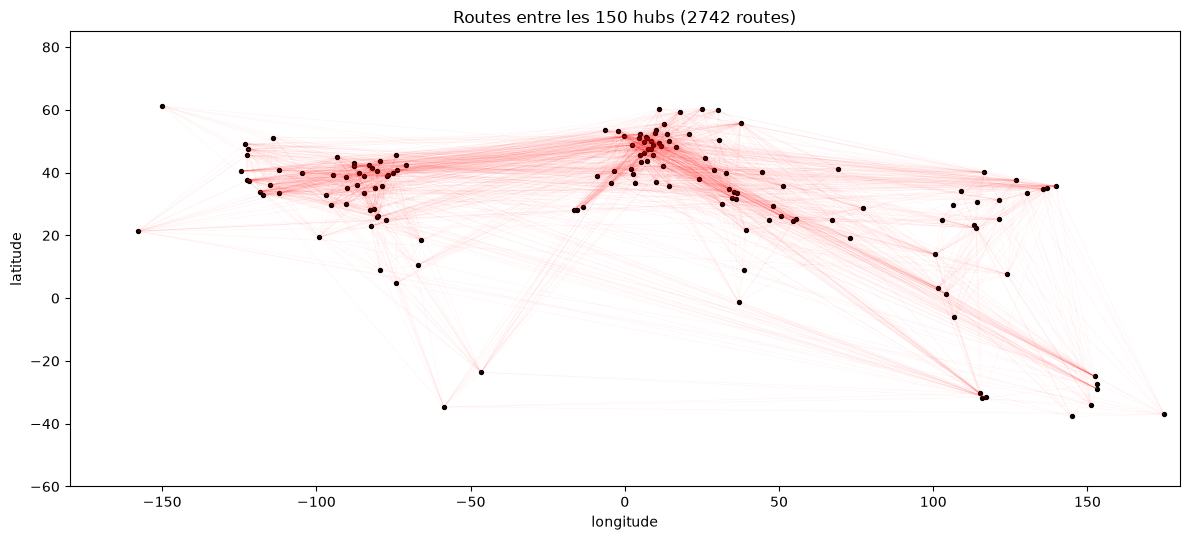

In [472]:
# routes pour les 150 aéroports avec le plus de connexions
hubs = set(df.sort_values("degre", ascending=False).head(150).index)
masque = np.array([(a in hubs) and (b in hubs) and (a < b) for a, b in zip(src_idx, dst_idx)])
segments = [[(lon[a], lat[a]), (lon[b], lat[b])] for a, b in zip(src_idx[masque], dst_idx[masque])]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.add_collection(LineCollection(segments, colors="red", linewidths=0.4, alpha=0.05))
h = df.loc[sorted(hubs)]
ax.scatter(h["lon"], h["lat"], s=8, color="black")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"Routes entre les 150 hubs ({masque.sum()} routes)")
plt.tight_layout()
plt.show()

Les vraies routes sont-elles plus courtes que des paires au hasard ? Cela motive des features géographiques.

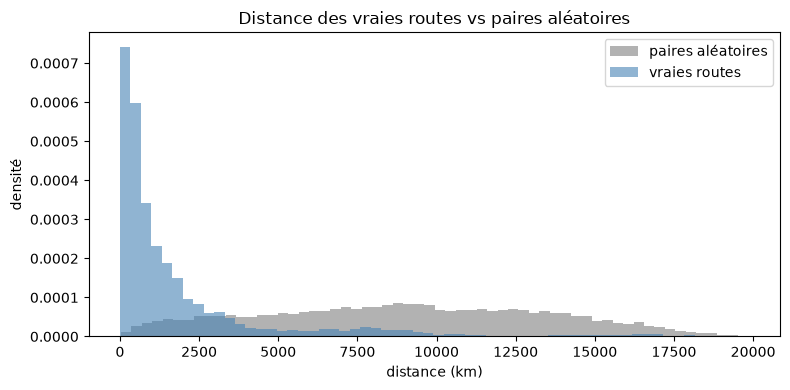

Distance médiane : vraies routes 814 km, paires aléatoires 8963 km
L'utilisation de long / lat est justifiée


In [473]:
rng = np.random.default_rng(0)
a = rng.integers(0, N, 20000)
b = rng.integers(0, N, 20000)
ok = a != b
d_alea = haversine(lon[a[ok]], lat[a[ok]], lon[b[ok]], lat[b[ok]])
d_vraies = haversine(lon[src_idx], lat[src_idx], lon[dst_idx], lat[dst_idx])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(d_alea, bins=60, density=True, alpha=0.6, label="paires aléatoires", color="gray")
ax.hist(d_vraies, bins=60, density=True, alpha=0.6, label="vraies routes", color="steelblue")
ax.set_xlabel("distance (km)")
ax.set_ylabel("densité")
ax.legend()
ax.set_title("Distance des vraies routes vs paires aléatoires")
plt.tight_layout()
plt.show()
print(f"Distance médiane : vraies routes {np.median(d_vraies):.0f} km, paires aléatoires {np.median(d_alea):.0f} km")

# Si la vraie distance entre moyenne entre les aéroport est inférieur à la distance moyenne d'aéroport aléatoire 
if np.median(d_vraies) < np.median(d_alea):
    print('L\'utilisation de long / lat est justifiée')
else:
    print('L\'utilisation de long / lat n\'est pas justifiée')

## Liens selon les pays

In [474]:
data_0.edge_index
indices_pays = th.tensor(LabelEncoder().fit_transform(data_0.country))
print(data_0.edge_index)
for titre, paires in [("vraies routes", data_0.edge_index)]:
    meme_pays = (indices_pays[paires[0]] == indices_pays[paires[1]]).float().mean()
    print(f"Test, {titre} : {meme_pays:.1%} relient deux aéroports du même pays")

tensor([[   0,    0,    1,  ..., 3361, 3361, 3362],
        [   1,    2,    0,  ..., 3359, 3362, 3361]])
Test, vraies routes : 57.4% relient deux aéroports du même pays


Paires aléatoires : 5.4% du même pays (contre 57.4% pour les vraies routes)


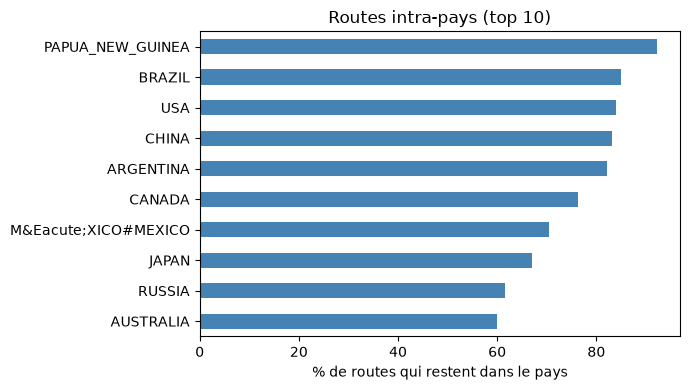

In [475]:
# baseline : part de paires du même pays si on tire deux aéroports au hasard
meme_alea = (indices_pays[a[ok]] == indices_pays[b[ok]]).float().mean()
print(f"Paires aléatoires : {meme_alea:.1%} du même pays (contre 57.4% pour les vraies routes)")

# Part des routes au départ du pays qui restent dans le pays (top 10)
ip = indices_pays.numpy()
tmp = pd.DataFrame({"pays": df["pays"].values[src_idx], "intra": ip[src_idx] == ip[dst_idx]})
principaux = df["pays"].value_counts().head(10).index
intra_pays = tmp[tmp["pays"].isin(principaux)].groupby("pays")["intra"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
intra_pays.mul(100).plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% de routes qui restent dans le pays")
ax.set_ylabel("")
ax.set_title("Routes intra-pays (top 10)")
plt.tight_layout()
plt.show()

## 8) Normalisation
Avant de normaliser, on regarde quelles en seraient l'effet`.

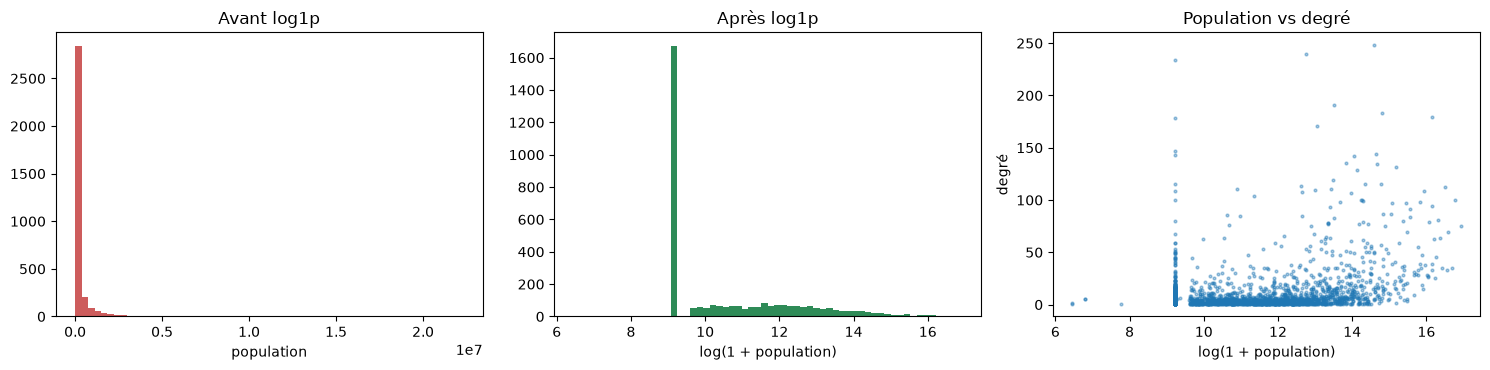

In [476]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(df["population"], bins=60, color="indianred")
ax[0].set_xlabel("population")
ax[0].set_title("Avant log1p")
ax[1].hist(np.log1p(df["population"]), bins=60, color="seagreen")
ax[1].set_xlabel("log(1 + population)")
ax[1].set_title("Après log1p")
ax[2].scatter(np.log1p(df["population"]), df["degre"], s=4, alpha=0.4)
ax[2].set_xlabel("log(1 + population)")
ax[2].set_ylabel("degré")
ax[2].set_title("Population vs degré")
plt.tight_layout()
plt.show()

In [477]:
# on construit des nouvelles features pour l'apprentissage du modèle GNN
# la population est transformée par log(1 + population) puis standardisée
# la longitude et la latitude sont transformées en coordonnées 3D sur la sphère
# les pays sont encodés en one-hot

import copy
x_brut = data_0.x.float()

# Normalisation : log(1 + population), puis standardisation de chaque colonne
x_log = x_brut.clone()
x_log[:, 2] = th.log1p(x_log[:, 2])
x_normalise = (x_log - x_log.mean(dim=0)) / x_log.std(dim=0)
log_pop = x_normalise[:, 2:3]

# Coordonnées 3D sur la sphère
lon_rad = th.deg2rad(x_brut[:, 0])
lat_rad = th.deg2rad(x_brut[:, 1])
coord_3d = th.stack([
    th.cos(lat_rad) * th.cos(lon_rad),  # x
    th.cos(lat_rad) * th.sin(lon_rad),  # y
    th.sin(lat_rad),                    # z
], dim=1)

# One-hot du pays : chaque pays reçoit un indice (LabelEncoder), puis on crée le vecteur one-hot
indices_pays = th.tensor(LabelEncoder().fit_transform(data_0.country))
pays_one_hot = F.one_hot(indices_pays).float()

features = {
    "normalisées": x_normalise,
    "3D": th.cat([coord_3d, log_pop], dim=1),
    "3D + pays": th.cat([coord_3d, log_pop, pays_one_hot], dim=1),
}

def avec_features(donnees, x):
    # même graphe et mêmes paires à prédire, seules les features des nœuds changent
    donnees_bis = copy.copy(donnees)
    donnees_bis.x = x
    return donnees_bis

colonnes = ["longitude", "latitude", "population"]
print("Features brutes :\n", pd.DataFrame(x_brut.numpy(), columns=colonnes).describe().loc[["mean", "std", "min", "max"]].round(2))
print("\nFeatures normalisées :\n", pd.DataFrame(x_normalise.numpy(), columns=colonnes).describe().loc[["mean", "std", "min", "max"]].round(2))

print()
for nom, x in features.items():
    print(f"{nom} : {x.size(1)} features par aéroport")

# Exemple : -179° et +179° de longitude sont loin en (lon, lat) mais proches en 3D
print()
for lon in [-179.0, 179.0]:
    l = th.deg2rad(th.tensor(lon))
    print(f"lon = {lon:+.0f}°, lat = 0° -> (x, y, z) = ({th.cos(l):.3f}, {th.sin(l):.3f}, 0.000)")

# Pourquoi le pays est utile : part des paires dans le même pays, vraies routes vs paires négatives
print()
for titre, paires in [("vraies routes", data_0.edge_index)]:
    meme_pays = (indices_pays[paires[0]] == indices_pays[paires[1]]).float().mean()
    print(f"Test, {titre} : {meme_pays:.1%} relient deux aéroports du même pays")

Features brutes :
       longitude  latitude   population
mean       0.70     23.02    338077.66
std       96.47     29.33   1262323.12
min     -179.87    -54.82       637.00
max      179.90     78.25  22315474.00

Features normalisées :
       longitude  latitude  population
mean       0.00      0.00        0.00
std        1.00      1.00        1.00
min       -1.87     -2.65       -2.31
max        1.86      1.88        3.46

normalisées : 3 features par aéroport
3D : 4 features par aéroport
3D + pays : 216 features par aéroport

lon = -179°, lat = 0° -> (x, y, z) = (-1.000, -0.017, 0.000)
lon = +179°, lat = 0° -> (x, y, z) = (-1.000, 0.017, 0.000)

Test, vraies routes : 57.4% relient deux aéroports du même pays


In [478]:
# les longitudes et latitudes sont normalisées en coordonnées 3D
# les pays one hot encodés
# on note que la variable pays est particulièrement interressantes pour prédire les liens

# on normalise les données en ajoutant les features 3D + pays_one_hot
data_1 = avec_features(data_0, features["normalisées"])
data_2 = avec_features(data_0, features["3D"])
data_3 = avec_features(data_0, features["3D + pays"])


print(data_1)
print(data_2)
print(data_3)

Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 3])
Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 4])
Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 216])


Corrélations entre les features continues et le degré (optionnel).

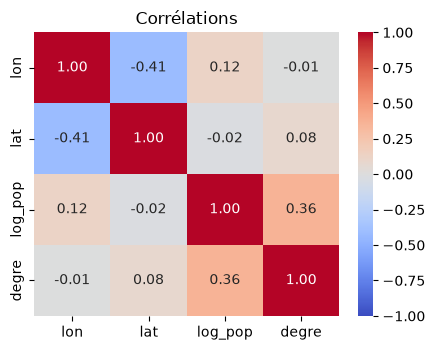

In [479]:
corr = pd.DataFrame({
    "lon": x_normalise[:, 0].numpy(),
    "lat": x_normalise[:, 1].numpy(),
    "log_pop": x_normalise[:, 2].numpy(),
    "degre": deg,
}).corr()
plt.figure(figsize=(4.5, 3.6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélations")
plt.tight_layout()
plt.show()

In [480]:
#  on divise le set en train , val et test et on sauvegarde les fichiers
# from turtle import save

from torch import save
from torch_geometric.transforms import RandomLinkSplit

#transform = RandomLinkSplit(is_undirected=True)

transform = RandomLinkSplit(is_undirected=True,split_labels=True)
# un seul split (fixé par la seed) : tous les jeux ont exactement les mêmes arêtes en train / val / test,
# seules les features des nœuds changent -> les comparaisons entre jeux de données sont équitables
th.manual_seed(0)
train_data_0, val_data_0, test_data_0 = transform(data_0)
train_data_1, val_data_1, test_data_1 = (avec_features(d, features["normalisées"]) for d in (train_data_0, val_data_0, test_data_0))
train_data_2, val_data_2, test_data_2 = (avec_features(d, features["3D"]) for d in (train_data_0, val_data_0, test_data_0))
train_data_3, val_data_3, test_data_3 = (avec_features(d, features["3D + pays"]) for d in (train_data_0, val_data_0, test_data_0))


save(data_0, '../data/data_0.pt')
save(data_1, '../data/data_1.pt')
save(data_2, '../data/data_2.pt')
save(data_3, '../data/data_3.pt')
save(train_data_0,'../data/train_data_0.pt')
save(val_data_0, '../data/val_data_0.pt')
save(test_data_0, '../data/test_data_0.pt')
save(train_data_1, '../data/train_data_1.pt')
save(val_data_1, '../data/val_data_1.pt')
save(test_data_1, '../data/test_data_1.pt')
save(train_data_2, '../data/train_data_2.pt')
save(val_data_2, '../data/val_data_2.pt')
save(test_data_2, '../data/test_data_2.pt')
save(train_data_3, '../data/train_data_3.pt')
save(val_data_3, '../data/val_data_3.pt')
save(test_data_3, '../data/test_data_3.pt')
print("sauvegarde terminée")

sauvegarde terminée
